In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df1 = pd.read_csv('features.csv')

In [40]:
df2 = pd.read_csv('stores.csv')

In [41]:
df3 = pd.read_csv('test.csv')

In [42]:
df4 = pd.read_csv('train.csv')

In [45]:
df1.dtypes

Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

In [46]:
df1['Date'] = pd.to_datetime(df1['Date'])

In [47]:
df3['Date'] = pd.to_datetime(df3['Date'])

In [48]:
df4['Date'] = pd.to_datetime(df4['Date'])

In [49]:
df1.duplicated().sum()

np.int64(0)

In [50]:
df3.tail(10)

,Store,Dept,Date,IsHoliday
115054,45,98,2013-05-24,False
115055,45,98,2013-05-31,False
115056,45,98,2013-06-07,False
115057,45,98,2013-06-14,False
115058,45,98,2013-06-21,False
115059,45,98,2013-06-28,False
115060,45,98,2013-07-05,False
115061,45,98,2013-07-12,False
115062,45,98,2013-07-19,False
115063,45,98,2013-07-26,False


In [51]:
df4.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False


In [52]:
df1.tail(10)

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
8180,45,2013-05-24,67.11,3.627,3249.34,481.82,58.48,1183.23,1309.30,NaN,NaN,False
8181,45,2013-05-31,65.88,3.646,6474.49,411.38,77.06,9.38,4227.27,NaN,NaN,False
8182,45,2013-06-07,70.71,3.633,9977.82,744.29,80.00,4825.71,3597.34,NaN,NaN,False
8183,45,2013-06-14,70.01,3.632,2471.44,517.87,348.54,2612.33,3459.39,NaN,NaN,False
8184,45,2013-06-21,70.13,3.626,4989.34,385.31,178.56,2463.42,3117.94,NaN,NaN,False
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False
8189,45,2013-07-26,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False


In [53]:
df3[['Store','Dept']].nunique()

Store    45
Dept     81
dtype: int64

In [6]:
joined = df2.merge(df3, how ='left')

In [7]:
joined = df2.merge(df4, how = 'left')

In [56]:
joined.head(10)

,Store,Type,Size,Dept,Date,Weekly_Sales,IsHoliday
0,1,A,151315,1,2010-02-05,24924.50,False
1,1,A,151315,1,2010-02-12,46039.49,True
2,1,A,151315,1,2010-02-19,41595.55,False
3,1,A,151315,1,2010-02-26,19403.54,False
4,1,A,151315,1,2010-03-05,21827.90,False
5,1,A,151315,1,2010-03-12,21043.39,False
6,1,A,151315,1,2010-03-19,22136.64,False
7,1,A,151315,1,2010-03-26,26229.21,False
8,1,A,151315,1,2010-04-02,57258.43,False
9,1,A,151315,1,2010-04-09,42960.91,False


In [57]:
joined.tail(10)

,Store,Type,Size,Dept,Date,Weekly_Sales,IsHoliday
421560,45,B,118221,98,2012-08-24,415.40,False
421561,45,B,118221,98,2012-08-31,346.04,False
421562,45,B,118221,98,2012-09-07,352.44,True
421563,45,B,118221,98,2012-09-14,605.96,False
421564,45,B,118221,98,2012-09-21,467.30,False
421565,45,B,118221,98,2012-09-28,508.37,False
421566,45,B,118221,98,2012-10-05,628.10,False
421567,45,B,118221,98,2012-10-12,1061.02,False
421568,45,B,118221,98,2012-10-19,760.01,False
421569,45,B,118221,98,2012-10-26,1076.80,False


In [15]:
joined['Store-Size'] = pd.qcut(joined['Size'], q=3, labels=['Small', 'Mid', 'Big'])

In [16]:
SizeProfit = joined.groupby('Store-Size', observed=False)['Weekly_Sales'].mean().sort_values(ascending= False)

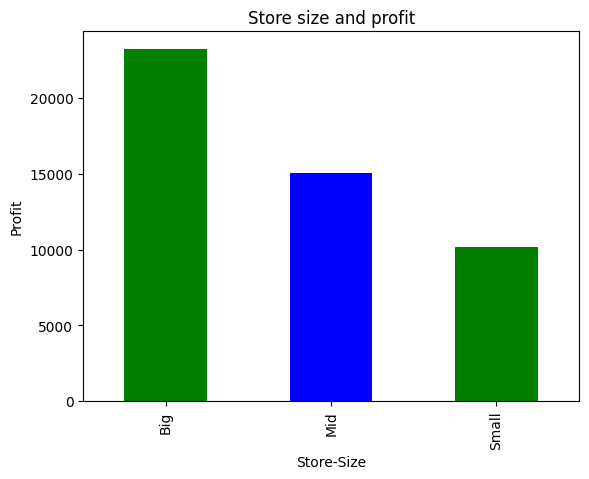

In [17]:
SizeProfit.plot(kind='bar', color=['Green', 'Blue'])
plt.title('Store size and profit')
plt.ylabel('Profit')
plt.show()

In [18]:
SizeProfit

Store-Size
Big      23231.406678
Mid      15035.091158
Small    10162.887906
Name: Weekly_Sales, dtype: float64

In [21]:
WeatherAndSales = df1.merge(df4, how = 'left')

In [22]:
WeatherAndSales['Temp_Group'] = pd.cut(WeatherAndSales['Temperature'], bins=10)
WeatherAndSales.groupby('Temp_Group', observed=False)['Weekly_Sales'].mean().sort_values(ascending = False)

Temp_Group
(36.406, 47.33]     16480.586512
(69.178, 80.102]    16344.423504
(25.482, 36.406]    16154.511117
(47.33, 58.254]     16154.092623
(58.254, 69.178]    15877.871798
(80.102, 91.026]    15695.101041
(14.558, 25.482]    14652.200698
(91.026, 101.95]    12732.562740
(3.634, 14.558]     11441.433100
(-7.399, 3.634]      8087.358986
Name: Weekly_Sales, dtype: float64

In [55]:
spike_threshold = df1['Fuel_Price'].quantile(0.9)

In [56]:
df1['Fuel_Spike'] = df1['Fuel_Price'] > spike_threshold

In [57]:
FuelAndStore = df4.merge(df1, on=['Store', 'Date'], how='left')

In [58]:
FuelAndStore = FuelAndStore.merge(df2[['Store', 'Type']], on='Store', how='left')

In [59]:
FuelAndStore.groupby(['Type', 'Fuel_Spike'])['Weekly_Sales'].mean()

Type  Fuel_Spike
A     False         20237.281911
      True          18898.188547
B     False         11994.671813
      True          14014.850670
C     False          9521.053040
      True           9506.156808
Name: Weekly_Sales, dtype: float64

In [60]:
FuelAndStore['Fuel_Level'] = pd.cut(FuelAndStore['Fuel_Price'], bins=3, labels=['Low', 'Medium', 'High'])

In [61]:
FuelAndStore.groupby(['Type','Fuel_Level'], observed=True)['Weekly_Sales'].mean()

Type  Fuel_Level
A     Low           20090.868459
      Medium        20413.719170
      High          19339.121270
B     Low           11914.563522
      Medium        11874.839854
      High          13466.741958
C     Low            9573.854309
      Medium         9493.166912
      High           9475.225640
Name: Weekly_Sales, dtype: float64

In [62]:
FuelAndStore['Fuel_Level'] = pd.qcut(FuelAndStore['Fuel_Price'], q=3, labels=['Low', 'Medium', 'High'])

In [63]:
FuelAndStore.groupby(['Type','Fuel_Level'], observed=True)['Weekly_Sales'].mean()

Type  Fuel_Level
A     Low           20111.771353
      Medium        20535.010782
      High          19615.264960
B     Low           11577.334236
      Medium        12026.416047
      High          13031.374040
C     Low            9682.607311
      Medium         9508.236623
      High           9373.507336
Name: Weekly_Sales, dtype: float64

In [73]:
df1 = df1.drop('Fuel_Spike', axis = 1)

In [74]:
markdowncols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4']
for col in markdowncols:
    df[col] = df[col].fillna(0)
df['isPromoWeek'] = (df[markdowncols] > 0).any(axis= 1)

In [75]:
promo_analysis = df.groupby(['Dept', 'isPromoWeek'])['Weekly_Sales'].mean().unstack()
promo_analysis.columns = ['Sales_No_Promo', 'Sales_With_Promo']
promo_analysis['Sales_Difference'] = promo_analysis['Sales_With_Promo'] - promo_analysis['Sales_No_Promo']

In [76]:
promo_analysis.sort_values('Sales_Difference', ascending=False).head(10)

,Sales_No_Promo,Sales_With_Promo,Sales_Difference
Dept,,,
92,72651.324164,79826.900965,7175.576801
90,44218.953848,47065.895188,2846.941340
87,12461.409440,15137.057836,2675.648396
7,23280.914979,25754.659459,2473.744479
82,14642.576053,16966.638686,2324.062633
38,60403.292497,62334.711581,1931.419084
40,44331.361016,45931.236087,1599.875072
18,6844.732142,8159.299915,1314.567773
2,43183.151544,44374.240734,1191.089190


In [77]:
df.drop(['isPromoWeek'], axis = 1)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.00,0.00,0.00,0.00,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.00,0.00,0.00,0.00,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.00,0.00,0.00,0.00,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.00,0.00,0.00,0.00,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.00,0.00,0.00,0.00,NaN,211.350143,8.106,False,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,False,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,0.00,18.82,2253.43,2340.01,192.170412,8.667,False,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,0.00,7.89,599.32,3990.54,192.327265,8.667,False,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,0.00,3.18,437.73,1537.49,192.330854,8.667,False,B,118221


In [43]:
df = df4.merge(df1, on=['Store', 'Date'], how='inner').merge(df2, on=['Store'], how='inner')

In [79]:
df.head(10)

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315
5,1,1,2010-03-12,21043.39,False,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False,A,151315
6,1,1,2010-03-19,22136.64,False,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False,A,151315
7,1,1,2010-03-26,26229.21,False,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False,A,151315
8,1,1,2010-04-02,57258.43,False,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False,A,151315
9,1,1,2010-04-09,42960.91,False,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False,A,151315


In [80]:
df.drop(['IsHoliday_y'], axis= 1, inplace=True)

In [81]:
df.rename(columns={'IsHoliday_x':'IsHoliday'}, inplace=True)

In [82]:
df.pivot_table(values='Weekly_Sales', index='Store', columns='Dept', aggfunc='mean')

Dept,1,2,3,4,5,6,7,8,9,10,...,90,91,92,93,94,95,96,97,98,99
Store,,,,,,,,,,,,,,,,,,,,,
1,22513.322937,46102.090420,13150.478042,36964.154476,24257.941119,4801.780140,24566.487413,35718.257622,28062.052238,31033.386364,...,82427.547832,64238.943427,135458.969510,71699.182378,63180.568182,120772.062168,33251.831639,35207.348811,11827.770769,306.091081
2,30777.980769,65912.922517,17476.563357,45607.666573,30555.315315,6808.382517,40477.837063,58707.369441,34375.864476,38845.854476,...,97611.537133,80610.380350,164840.230979,70581.977063,70018.672517,143588.751888,34319.063846,40697.204056,14035.400839,475.896905
3,7328.621049,16841.775664,5509.300769,8434.186503,11695.366573,2012.411818,10044.341608,8310.254196,9062.007692,10871.944126,...,1540.049161,318.685594,7568.280210,NaN,656.294444,15745.528252,3934.540000,343.437357,30.570833,NaN
4,36979.940070,93639.315385,19012.491678,56603.400140,45668.406783,8241.777692,50728.151399,62949.723776,34437.170979,37269.667413,...,89248.965524,66535.407203,159365.107902,67815.163007,68159.106573,147236.473706,38346.573077,39339.238951,15009.249371,623.182381
5,9774.553077,12317.953287,4101.085175,9860.806783,6699.202238,1191.057622,6124.484336,13735.709441,7919.805944,9783.395385,...,3059.520000,1457.221678,7759.205594,NaN,411.431486,19340.693986,5985.671119,667.070315,29.976087,NaN
6,23867.553776,50269.437273,16806.638811,34187.366503,34465.307622,7225.566643,34526.870420,47577.719790,48271.060140,47436.477902,...,53715.366084,45270.405175,99024.796503,41359.651189,41701.693497,89208.786294,30450.542238,20637.667063,9728.100629,388.636750
7,9542.801259,22603.690769,8633.536923,14950.518601,13860.350490,6329.928811,10925.757063,13970.619371,29722.736084,21136.560280,...,13858.405874,10263.880000,26530.890559,1328.178252,699.332522,34208.097273,1123.383217,4374.927902,260.886596,15.000000
8,14789.827343,35729.821748,10683.305105,21089.309301,19838.849231,3395.425455,20268.743776,26438.524336,11792.661678,20666.433776,...,39333.566154,31530.560909,60465.630000,27515.635315,25442.578042,62951.463706,16.986667,16978.366503,6880.466434,298.153714
9,11846.558252,24969.477413,7497.356783,17165.947762,19282.746014,2806.416364,13826.694336,21424.470699,13196.569720,12810.480350,...,2981.249510,869.273287,14123.063147,21.240000,599.112568,29575.050769,3596.107762,372.655556,27.930000,NaN


In [83]:
df.loc[df['Weekly_Sales']<=0]

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
846,1,6,2012-08-10,-139.65,False,85.05,3.494,11436.22,245.0,6.85,6964.26,4836.22,221.958433,6.908,A,151315
2384,1,18,2012-05-04,-1.27,False,75.55,3.749,21290.13,NaN,69.89,4977.35,3261.04,221.671800,7.143,A,151315
6048,1,47,2010-02-19,-863.00,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
6049,1,47,2010-03-12,-698.00,False,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,A,151315
6051,1,47,2010-10-08,-58.00,False,63.93,2.633,NaN,NaN,NaN,NaN,NaN,211.746754,7.838,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419597,45,80,2010-02-12,-0.43,True,27.73,2.773,NaN,NaN,NaN,NaN,NaN,181.982317,8.992,B,118221
419598,45,80,2010-02-19,-0.27,False,31.27,2.745,NaN,NaN,NaN,NaN,NaN,182.034782,8.992,B,118221
419603,45,80,2010-04-16,-1.61,False,54.28,2.899,NaN,NaN,NaN,NaN,NaN,181.692477,8.899,B,118221
419614,45,80,2010-07-02,-0.27,False,76.61,2.815,NaN,NaN,NaN,NaN,NaN,182.318780,8.743,B,118221


In [84]:
df = df.loc[df['Weekly_Sales'] > 0]

In [85]:
df.shape

(420212, 16)

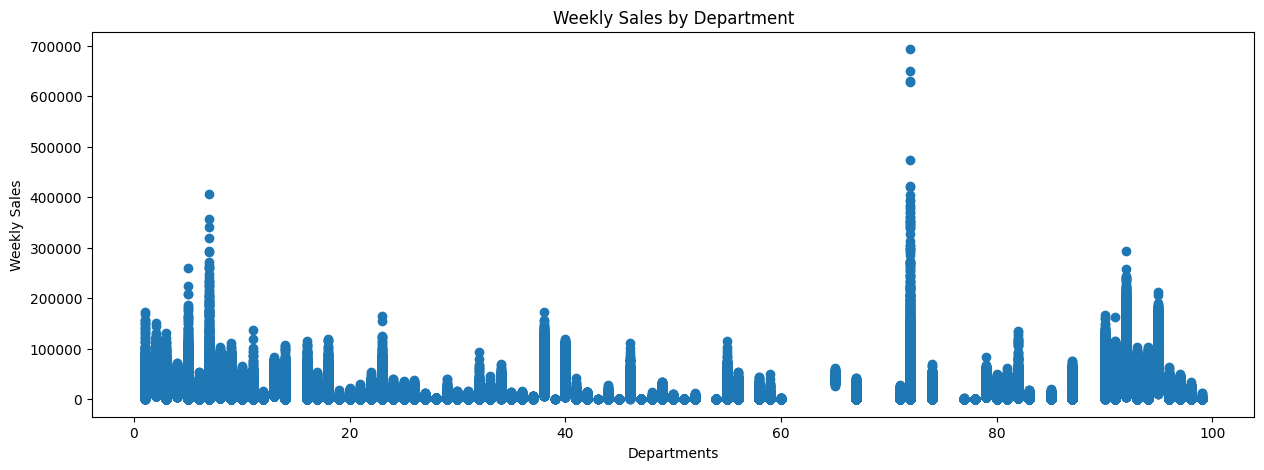

In [86]:
x = df['Dept']
y = df['Weekly_Sales']
plt.figure(figsize=(15,5))
plt.title('Weekly Sales by Department')
plt.xlabel('Departments')
plt.ylabel('Weekly Sales')
plt.scatter(x,y)
plt.show()

In [87]:
df['Unemployment'][:10]._append(df['Unemployment'][-10:])

0         8.106
1         8.106
2         8.106
3         8.106
4         8.106
5         8.106
6         8.106
7         8.106
8         7.808
9         7.808
421560    8.684
421561    8.684
421562    8.684
421563    8.684
421564    8.684
421565    8.684
421566    8.667
421567    8.667
421568    8.667
421569    8.667
Name: Unemployment, dtype: float64

In [88]:
print(f"Min unemployment: {df['Unemployment'].min()}")
print(f"Max unemployment: {df['Unemployment'].max()}")
print(f"Range: {df['Unemployment'].max() - df['Unemployment'].min()}")

Min unemployment: 3.879
Max unemployment: 14.313
Range: 10.434000000000001


In [52]:
df['Date'] = pd.to_datetime(df['Date'])

In [50]:
SalesAndUnemployment = df
SalesAndUnemployment['Employees'] = pd.cut(SalesAndUnemployment['Unemployment'], bins=3, labels=['Low','Medium','High'])

In [51]:
SalesAndUnemployment.groupby('Employees', observed=True)['Weekly_Sales'].mean()

Employees
Low       15789.190987
Medium    16283.213371
High      14316.251094
Name: Weekly_Sales, dtype: float64

In [53]:
SalesAndUnemployment['Month'] = SalesAndUnemployment['Date'].dt.to_period('M')

In [54]:
SalesAndUnemployment.groupby(['Month', 'Employees'], observed=True)['Weekly_Sales'].mean().unstack()

Employees,Low,Medium,High
Month,,,
2010-02,12547.953017,16972.825695,15733.483911
2010-03,12339.858451,16297.681875,14158.885007
2010-04,12636.847137,16911.552799,14001.913913
2010-05,12874.823067,17178.368702,14009.643685
2010-06,13611.611045,17601.029665,14365.401095
2010-07,13591.238292,17062.211579,13635.654629
2010-08,13744.852638,17272.958218,13892.700121
2010-09,12710.447540,16154.893546,13491.247397
2010-10,13515.258089,15331.993395,13002.580872


In [ ]:
df.drop(['Employees'], axis=1, inplace=True)

In [ ]:
df.head(5)

In [ ]:
print(f"CPImin: {df['CPI'].min()}")
print(f"CPImax: {df['CPI'].max()}")
print(f"CPIdifference: {df['CPI'].max() - df['CPI'].min()}")

In [ ]:
CPIAndSales = df
CPIAndSales['CPILevels'] = pd.cut(CPIAndSales['CPI'], bins=3, labels=['Low', 'Medium', 'High'])
CPIAndSales['Month'] = df['Date'].dt.to_period('M')
CPIAndSales.groupby(['Month', 'CPILevels', 'Type', 'Size'])['Weekly_Sales'].mean().round(2).unstack()

In [ ]:
Holidays = df
Holidays['Weather'] = pd.cut(Holidays['Temperature'], bins = 3, labels=['Cold', 'Mild', 'Hot'])
Holidays.pivot_table(values='Weekly_Sales', index=['Weather','IsHoliday'], columns='Type', aggfunc='mean')

In [ ]:
Holidays.groupby(['Weather', 'Type','IsHoliday'])['Weekly_Sales'].mean().round(2)

In [ ]:
print(df.groupby('Dept')['CPI'].agg(['min', 'max']))

In [128]:
forecasti1 = df

In [130]:
forecasti1.sort_values(['Dept', 'Date'])

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type,Size,Employees,Month,Lag1,Lag_4,Lag_52,lag_1,lag_4,lag_52
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,A,151315,Medium,2010-02,NaN,NaN,NaN,NaN,NaN,NaN
10244,2,1,2010-02-05,35034.06,False,40.19,2.572,NaN,NaN,NaN,...,A,202307,Medium,2010-02,27390.81,21904.47,39886.06,27390.81,21904.47,39886.06
20482,3,1,2010-02-05,6453.58,False,45.71,2.572,NaN,NaN,NaN,...,B,37392,Medium,2010-02,41615.24,30789.27,55729.13,41615.24,30789.27,55729.13
29518,4,1,2010-02-05,38724.42,False,43.76,2.598,NaN,NaN,NaN,...,A,205863,Medium,2010-02,11351.24,9750.12,15836.73,11351.24,9750.12,15836.73
39790,5,1,2010-02-05,9323.89,False,39.70,2.572,NaN,NaN,NaN,...,B,34875,Low,2010-02,57046.29,41292.92,78489.30,57046.29,41292.92,78489.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391058,41,99,2012-10-12,230.03,False,39.38,3.760,1570.23,NaN,26.31,...,A,196321,Low,2012-10,934.88,20.12,0.04,934.88,20.12,0.04
78655,8,99,2012-10-19,0.03,False,62.99,3.594,1260.59,NaN,6.50,...,A,155078,Low,2012-10,50.02,10.06,10.00,50.02,10.06,10.00
78656,8,99,2012-10-26,0.01,False,64.74,3.506,2679.05,20.38,6.00,...,A,155078,Low,2012-10,0.03,0.04,80.00,0.03,0.04,80.00
314047,32,99,2012-10-26,12.00,False,47.22,3.686,8968.72,104.91,200.00,...,A,203007,Medium,2012-10,60.00,0.13,0.02,60.00,0.13,0.02


In [131]:
forecasti1['lag_1'] = forecasti1.groupby('Dept')['Weekly_Sales'].shift(1)
forecasti1['lag_4'] = forecasti1.groupby('Dept')['Weekly_Sales'].shift(4)
forecasti1['lag_52'] = forecasti1.groupby('Dept')['Weekly_Sales'].shift(52)

In [132]:
dept_sample = forecasti1[forecasti1['Dept'] == 5][['Date', 'Weekly_Sales', 'lag_1', 'lag_4', 'lag_52']].head(10)

In [124]:
print(forecasti1[['Weekly_Sales', 'Lag1', 'Lag_4', 'Lag_52']].corr())

              Weekly_Sales      Lag1     Lag_4    Lag_52
Weekly_Sales      1.000000  0.946963  0.923891  0.813324
Lag1              0.946963  1.000000  0.922100  0.793922
Lag_4             0.923891  0.922100  1.000000  0.800008
Lag_52            0.813324  0.793922  0.800008  1.000000


In [153]:
df['last_year_sales'] = df.groupby('Dept')['Weekly_Sales'].shift(52)

In [154]:
df['prediction_error'] = df['Weekly_Sales'] - df['last_year_sales']

In [155]:
df['absolute_error'] = abs(df['prediction_error'])

In [156]:
df['percent_error'] = (df['prediction_error'] / df['last_year_sales']) * 100

In [157]:
print(df[['Date', 'Weekly_Sales', 'last_year_sales', 'prediction_error', 'percent_error']].dropna())

             Date  Weekly_Sales  last_year_sales  prediction_error  \
52     2011-02-04      21665.76         24924.50          -3258.74   
53     2011-02-11      37887.17         46039.49          -8152.32   
54     2011-02-18      46845.87         41595.55           5250.32   
55     2011-02-25      19363.83         19403.54            -39.71   
56     2011-03-04      20327.61         21827.90          -1500.29   
...           ...           ...              ...               ...   
421565 2012-09-28        508.37           727.05           -218.68   
421566 2012-10-05        628.10           894.98           -266.88   
421567 2012-10-12       1061.02           996.40             64.62   
421568 2012-10-19        760.01          1058.84           -298.83   
421569 2012-10-26       1076.80          1167.90            -91.10   

        percent_error  
52         -13.074445  
53         -17.707234  
54          12.622312  
55          -0.204653  
56          -6.873268  
...            

In [158]:
print(f"Average absolute error: ${df['absolute_error'].mean():.2f}")
print(f"Average percent error: {df['percent_error'].mean():.1f}%")

Average absolute error: $5550.89
Average percent error: 5933.6%


In [159]:
print(df['last_year_sales'].describe())
print(df['last_year_sales'].value_counts().head(10))

count    416076.000000
mean      16085.687322
std       22791.265475
min           0.010000
25%        2130.392500
50%        7698.685000
75%       20332.040000
max      693099.360000
Name: last_year_sales, dtype: float64
last_year_sales
10.00    346
5.00     278
20.00    223
15.00    205
10.47    166
1.00     161
12.00    154
11.97    153
2.00     144
7.00     141
Name: count, dtype: int64


In [160]:
print(f"Median absolute error: ${df['absolute_error'].median():.2f}")

# Or filter out tiny last_year_sales
normal = df[df['last_year_sales'] > 1000]
print(f"Normal weeks only - percent error: {normal['percent_error'].mean():.1f}%")

Median absolute error: $1371.10
Normal weeks only - percent error: 19.0%


In [161]:
dept_variance = df.groupby('Dept')['Weekly_Sales'].std().sort_values()

In [162]:
dept_variance.head(10)

Dept
43      1.027745
78      7.641214
39      9.511561
45     24.274260
51     28.551357
54    145.312333
47    183.226485
60    283.837789
77    337.489394
28    464.171254
Name: Weekly_Sales, dtype: float64

In [163]:
dept_variance.tail(10)

Dept
93    22592.823726
38    23966.913901
2     25176.756920
94    25273.756981
91    26247.462296
7     27985.082741
90    32462.020077
95    38200.536452
72    44674.185444
92    49413.732570
Name: Weekly_Sales, dtype: float64

In [164]:
dept_error = df[df['last_year_sales'] > 1000].groupby('Dept')['percent_error'].mean().abs().sort_values()
print("\nMost predictable (lowest error):")
print(dept_error.head(10))
print("\nMost chaotic (highest error):")
print(dept_error.tail(10))


Most predictable (lowest error):
Dept
31    0.833233
12    1.844742
52    2.195112
36    2.378415
50    2.974503
37    3.332373
65    3.624124
41    4.445807
85    4.498110
49    4.612174
Name: percent_error, dtype: float64

Most chaotic (highest error):
Dept
16    55.010499
91    55.922029
59    57.963180
18    66.126458
90    72.386962
77    73.771041
54    91.515324
99    93.386220
93    96.004904
47    96.053430
Name: percent_error, dtype: float64


In [165]:
dept_summary = df.groupby('Dept').agg({
    'Weekly_Sales': ['std', 'mean'],
    'percent_error': 'mean'
}).round(2)

dept_summary.columns = ['sales_std', 'sales_mean', 'avg_error']
dept_summary['cv'] = dept_summary['sales_std'] / dept_summary['sales_mean']

print(dept_summary.sort_values('cv').head(10))
print(dept_summary.sort_values('cv').tail(10))


      sales_std  sales_mean  avg_error        cv
Dept                                            
65      7086.89    45441.71      -3.62  0.155956
37       885.70     3112.28       3.50  0.284582
38     23966.91    61090.62       7.35  0.392317
40     21903.88    44900.70      12.81  0.487829
4      13261.14    25974.63      12.92  0.510542
13     16237.53    30663.80      15.03  0.529534
95     38200.54    69824.42      14.88  0.547094
44      2575.00     4667.11    3087.77  0.551733
34      8955.72    15631.79    2321.69  0.572917
2      25176.76    43607.02      18.04  0.577356
      sales_std  sales_mean  avg_error        cv
Dept                                            
7      27985.08    24161.24     325.70  1.158263
58      4308.81     3703.76     100.32  1.163361
51        28.55       22.72     297.29  1.256602
54       145.31      113.09     340.92  1.284906
41      2716.55     1971.08     309.74  1.378204
47       183.23      129.29     328.45  1.417202
56      5981.03     